In [ ]:
!pip install -q transformers torch torchvision pillow matplotlib

In [ ]:
# CELL 1 — Load pretrained LoveDA SegFormer
# NO TRAINING / NO DATASET

import sys
import subprocess

# Make sure required packages exist
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "transformers", "torchvision", "pillow", "matplotlib"
])

import torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from transformers import SegformerForSemanticSegmentation

MODEL_ID = "wu-pr-gw/segformer-b2-finetuned-with-LoveDA"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Transformers:", __import__("transformers").__version__)
print("PyTorch:", torch.__version__)
print("Device:", device)

# Load THEIR pretrained weights
model = SegformerForSemanticSegmentation.from_pretrained(
    MODEL_ID
).to(device)

model.eval()

print("\nMODEL LOADED SUCCESSFULLY")
print("\nClasses:")
for idx, label in model.config.id2label.items():
    print(f"  {idx}: {label}")

Transformers: 5.16.1
PyTorch: 2.11.0+cpu
Device: cpu


config.json:   0%|          | 0.00/1.41k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  110MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  109MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]


MODEL LOADED SUCCESSFULLY

Classes:
  0: Ignore
  1: Background
  2: Building
  3: Road
  4: Water
  5: Barren
  6: Forest
  7: Agricultural


Saving 1.png to 1.png
Loaded: 1.png
Image size: (1024, 1024)


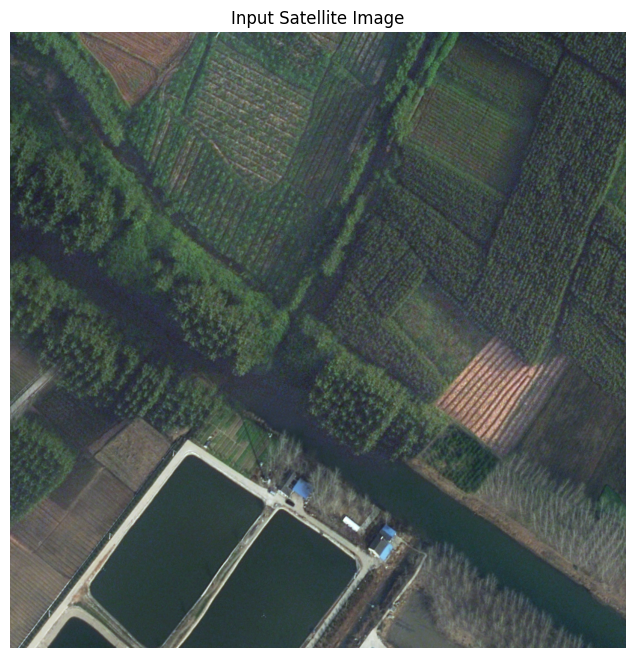

In [ ]:
# CELL 2 — Upload a satellite image

from google.colab import files
from PIL import Image
import io
import matplotlib.pyplot as plt

uploaded = files.upload()

filename = next(iter(uploaded))
image = Image.open(io.BytesIO(uploaded[filename])).convert("RGB")

print("Loaded:", filename)
print("Image size:", image.size)

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title("Input Satellite Image")
plt.axis("off")
plt.show()

In [ ]:
# CELL 3 — Preprocess image and run pretrained SegFormer

import torch
import torch.nn.functional as F
import numpy as np
from torchvision import transforms

# LoveDA preprocessing
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Prepare image
input_tensor = transform(image).unsqueeze(0).to(device)

print("Running inference...")
print("Input shape:", input_tensor.shape)

# Inference only — NO training
with torch.no_grad():
    outputs = model(pixel_values=input_tensor)

# Resize prediction to original image dimensions
logits = F.interpolate(
    outputs.logits,
    size=(image.height, image.width),
    mode="bilinear",
    align_corners=False
)

prediction = logits.argmax(dim=1)[0].cpu().numpy()

print("Inference complete.")
print("Output mask shape:", prediction.shape)
print("Classes present:", sorted(np.unique(prediction).tolist()))

Running inference...
Input shape: torch.Size([1, 3, 512, 512])
Inference complete.
Output mask shape: (1024, 1024)
Classes present: [1, 3, 4, 6, 7]


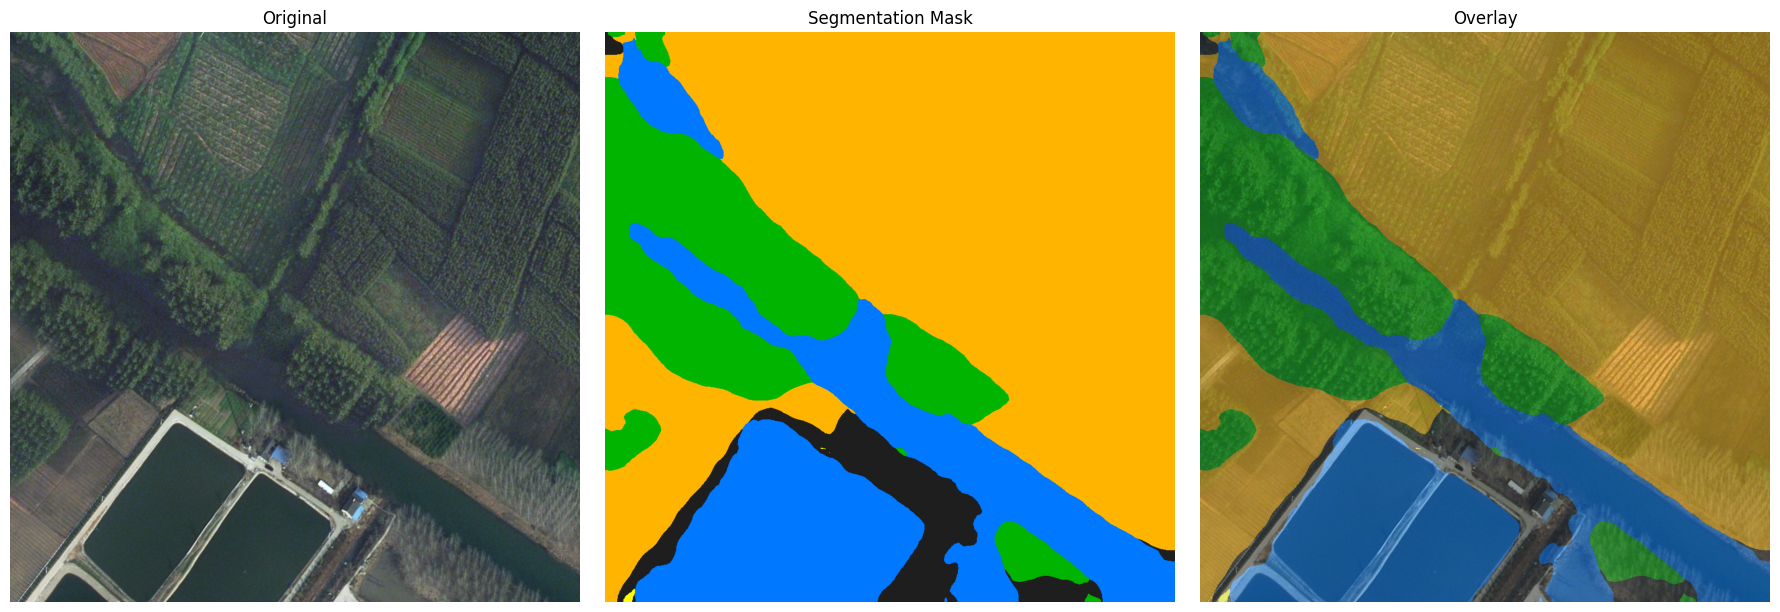


Pixel distribution:
1: Background   → 5.40%
3: Road         → 0.03%
4: Water        → 22.18%
6: Forest       → 16.97%
7: Agricultural → 55.42%


In [ ]:
# CELL 4 — Visualize segmentation result

import numpy as np
import matplotlib.pyplot as plt

# Class colors
palette = np.array([
    [0,   0,   0],       # 0 Ignore
    [30,  30,  30],      # 1 Background
    [255, 0,   0],       # 2 Building
    [255, 255, 0],       # 3 Road
    [0,   120, 255],     # 4 Water
    [180, 120, 60],      # 5 Barren
    [0,   180, 0],       # 6 Forest
    [255, 180, 0],       # 7 Agricultural
], dtype=np.uint8)

mask_rgb = palette[prediction]

# Resize original image to mask dimensions for a clean comparison
original = np.array(image.resize(
    (prediction.shape[1], prediction.shape[0])
))

# Overlay
overlay = (
    0.55 * original.astype(np.float32)
    + 0.45 * mask_rgb.astype(np.float32)
).clip(0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mask_rgb)
axes[1].set_title("Segmentation Mask")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Print pixel distribution
print("\nPixel distribution:")
total = prediction.size

for class_id in sorted(np.unique(prediction)):
    count = np.sum(prediction == class_id)
    label = model.config.id2label.get(class_id, str(class_id))
    print(f"{class_id}: {label:12s} → {count/total*100:.2f}%")

In [ ]:
# CELL 6 — Download/save the exact pretrained model + config

from huggingface_hub import snapshot_download

MODEL_ID = "wu-pr-gw/segformer-b2-finetuned-with-LoveDA"

MODEL_DIR = snapshot_download(
    repo_id=MODEL_ID,
    local_dir="/content/segformer-b2-loveda"
)

print("Model downloaded to:")
print(MODEL_DIR)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Model downloaded to:
/content/segformer-b2-loveda


In [ ]:
# CELL 7 — Package model for download

import shutil
from google.colab import files

zip_path = shutil.make_archive(
    "/content/segformer-b2-loveda",
    "zip",
    "/content/segformer-b2-loveda"
)

print("Created:", zip_path)

files.download(zip_path)

Created: /content/segformer-b2-loveda.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>